In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error,  r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

In [42]:
csv_path = Path("Housing.csv")
df = pd.read_csv(csv_path)
target_col = "price"
y = df[target_col].values
X = df.drop(columns=[target_col, "rownames"])
X.head(), target_col

(   lotsize  bedrooms  bathrms  stories driveway recroom fullbase gashw airco  \
 0     5850         3        1        2      yes      no      yes    no    no   
 1     4000         2        1        1      yes      no       no    no    no   
 2     3060         3        1        1      yes      no       no    no    no   
 3     6650         3        1        2      yes     yes       no    no    no   
 4     6360         2        1        1      yes      no       no    no    no   
 
    garagepl prefarea  
 0         1       no  
 1         0       no  
 2         0       no  
 3         0       no  
 4         0       no  ,
 'price')

In [43]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
numeric_features, categorical_features

(['lotsize', 'bedrooms', 'bathrms', 'stories', 'garagepl'],
 ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea'])

In [44]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
rf = RandomForestRegressor(random_state=42, n_estimators=400, n_jobs=-1)
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", rf)
])
param_grid = {
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__max_features": [0.8, "sqrt", "log2"]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipe, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1, verbose=0)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
grid_search.best_params_

{'rf__max_depth': 10,
 'rf__max_features': 0.8,
 'rf__min_samples_leaf': 1,
 'rf__min_samples_split': 2}

In [46]:
def rmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

y_pred_train = best_model.predict(X_test)
print(f"Target: {target_col}")
print(f"Best params: {grid_search.best_params_}")
print(f"Train RMSE: {rmse(y_test, y_pred_train):.4f}")
print(f"Train R2: {r2_score(y_test, y_pred_train):.2f}")

Target: price
Best params: {'rf__max_depth': 10, 'rf__max_features': 0.8, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2}
Train RMSE: 17515.6633
Train R2: 0.54


In [47]:
oh = None
if categorical_features:
  oh = best_model.named_steps["preprocessor"].transformers_[1][1].named_steps["onehot"]
num_names = numeric_features
cat_names = oh.get_feature_names_out(categorical_features).tolist() if oh is not None else []
feature_names = num_names + cat_names
feature_names

['lotsize',
 'bedrooms',
 'bathrms',
 'stories',
 'garagepl',
 'driveway_no',
 'driveway_yes',
 'recroom_no',
 'recroom_yes',
 'fullbase_no',
 'fullbase_yes',
 'gashw_no',
 'gashw_yes',
 'airco_no',
 'airco_yes',
 'prefarea_no',
 'prefarea_yes']

In [48]:
importances = best_model.named_steps["rf"].feature_importances_
imp_df = (pd.DataFrame({"feature": feature_names if len(feature_names)== len(importances) else [f"f{i}" for i in range(len(importances))]
, "importance": importances})
.sort_values("importance", ascending=False)
.head(10))
imp_df

,feature,importance
0,lotsize,0.446697
2,bathrms,0.131981
4,garagepl,0.078165
3,stories,0.056512
1,bedrooms,0.050220
14,airco_yes,0.049936
13,airco_no,0.046005
9,fullbase_no,0.021111
10,fullbase_yes,0.019961
15,prefarea_no,0.017690


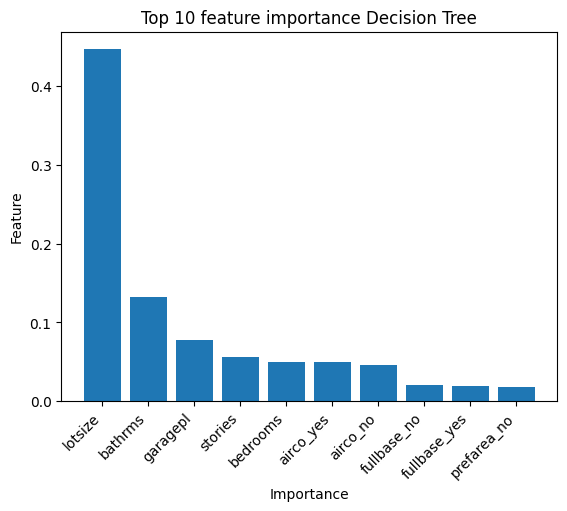

In [49]:
plt.figure()
plt.bar(imp_df["feature"], imp_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 feature importance Decision Tree")
plt.show()